# Dynamic Regime Indicator (Path Length Efficiency)

This notebook demonstrates a purely data-driven Regime Filter using the concept of **Cumulative Price Traveled** and **Efficiency Ratio**. 

Instead of a hardcoded lookback (e.g., 50 days), we mathematically stretch the lookback window backwards in time until the stock has traveled a cumulative absolute distance of `target` (e.g., 50%). We then measure the net directional distance traveled over that dynamic window to score the trend efficiency.

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import matplotlib.dates as mdates

plt.rcParams['figure.figsize'] = (18, 12)
plt.rcParams['axes.grid'] = True

## 1. Load Data for 5 Stocks
We randomly sample 5 stocks from our dataset to visualize.

In [2]:
DATA_DIR = r'D:\0dot1_Aug_2016_master\data\mstock_mtf_daily_data'

all_files = [f for f in os.listdir(DATA_DIR) if f.endswith('.csv')]

loaded_stocks = {}
for file in all_files:
    try:
        df = pd.read_csv(os.path.join(DATA_DIR, file))
        df['Date'] = pd.to_datetime(df['Date'])
        df = df.sort_values('Date').reset_index(drop=True)
        
        if len(df) > 1000:
            loaded_stocks[file.replace('.csv', '')] = df
            
        if len(loaded_stocks) >= 5:
            break
    except Exception as e:
        continue

print(f"Loaded {len(loaded_stocks)} stocks for testing.")

Loaded 5 stocks for testing.


## 2. Dynamic Indicator Logic
Calculates the dynamic lookback length `N` and the resulting `Efficiency Ratio`.

In [3]:
def calculate_dynamic_regime(data, target=0.50):
    data = data.copy()
    data['abs_ret'] = data['Close'].pct_change().abs()
    
    lookbacks = []
    distance_travelled = []
    efficiency = []
    
    abs_rets = data['abs_ret'].values
    closes = data['Close'].values
    
    for i in range(len(data)):
        if i == 0 or np.isnan(abs_rets[i]):
            lookbacks.append(np.nan)
            distance_travelled.append(np.nan)
            efficiency.append(np.nan)
            continue
            
        cum_sum = 0
        j = i
        while j >= 0 and cum_sum < target:
            if not np.isnan(abs_rets[j]):
                cum_sum += abs_rets[j]
            j -= 1
            
        if cum_sum < target:
            lookbacks.append(np.nan)
            distance_travelled.append(np.nan)
            efficiency.append(np.nan)
        else:
            n_days = i - j
            lookbacks.append(n_days)
            
            # Calculate net return from j to i
            # Note: j is the day where cum_sum exceeded target
            net_return = (closes[i] - closes[j]) / closes[j]
            distance_travelled.append(net_return)
            eff = net_return / cum_sum
            efficiency.append(eff)
            
    data['dynamic_lookback'] = lookbacks
    data['distance_travelled'] = distance_travelled
    data['efficiency_ratio'] = efficiency
    return data

print("Indicator function loaded.")

Indicator function loaded.


## 3. Plotting Logic
Plots 3 subplots: Price, Dynamic Lookback, and Efficiency Ratio.

In [4]:
def plot_regime(data, symbol, start_idx, num_days=63):
    end_idx = min(start_idx + num_days, len(data) - 1)
    plot_data = data.iloc[start_idx:end_idx+1].copy().reset_index(drop=True)
    
    if plot_data.empty:
        return

    fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(18, 12), gridspec_kw={'height_ratios': [3, 1, 1]})
    width = 0.65
    
    # 1. Price Plot
    ax1.plot(plot_data.index, plot_data['Close'], color='black', linewidth=1.5)
    ax1.set_title(f'{symbol} - 3 Month Snapshot ({plot_data.iloc[0]["Date"].strftime("%Y-%m-%d")} to {plot_data.iloc[-1]["Date"].strftime("%Y-%m-%d")})')
    ax1.set_ylabel('Price')
    
    # 2. Distance Travelled Plot
    ax2.plot(plot_data.index, plot_data['distance_travelled'], color='orange', linewidth=2)
    ax2.axhline(0, color='black', linestyle='--', linewidth=1)
    ax2.set_ylabel('Distance Travelled')
    ax2.set_title('Net Distance Travelled over Dynamic Window')
    
    # 3. Efficiency Ratio Plot
    ax3.plot(plot_data.index, plot_data['efficiency_ratio'], color='blue', linewidth=2)
    ax3.axhline(0, color='black', linestyle='--', linewidth=1)
    ax3.axhline(0.3, color='green', linestyle=':', linewidth=1.5)
    ax3.axhline(-0.3, color='red', linestyle=':', linewidth=1.5)
    ax3.set_ylabel('Efficiency Ratio')
    ax3.set_title('Regime Score (-1 to +1)')
    ax3.set_ylim(-1.1, 1.1)

    # Formatting X-axis
    tick_step = max(1, len(plot_data) // 10)
    ticks = list(range(0, len(plot_data), tick_step))
    labels = [plot_data.loc[t, 'Date'].strftime('%Y-%m-%d') for t in ticks]
    
    for ax in [ax1, ax2, ax3]:
        ax.set_xticks(ticks)
        ax.set_xticklabels(labels if ax == ax3 else [], rotation=45 if ax == ax3 else 0, ha='right')

    plt.tight_layout()
    plt.show()

print("Plotting function loaded.")

Plotting function loaded.


## 4. Run Indicator and Render Case Studies
We calculate the indicator and plot two 3-month slices per stock.


Processing 360ONE...



--- 360ONE Slice 1 ---


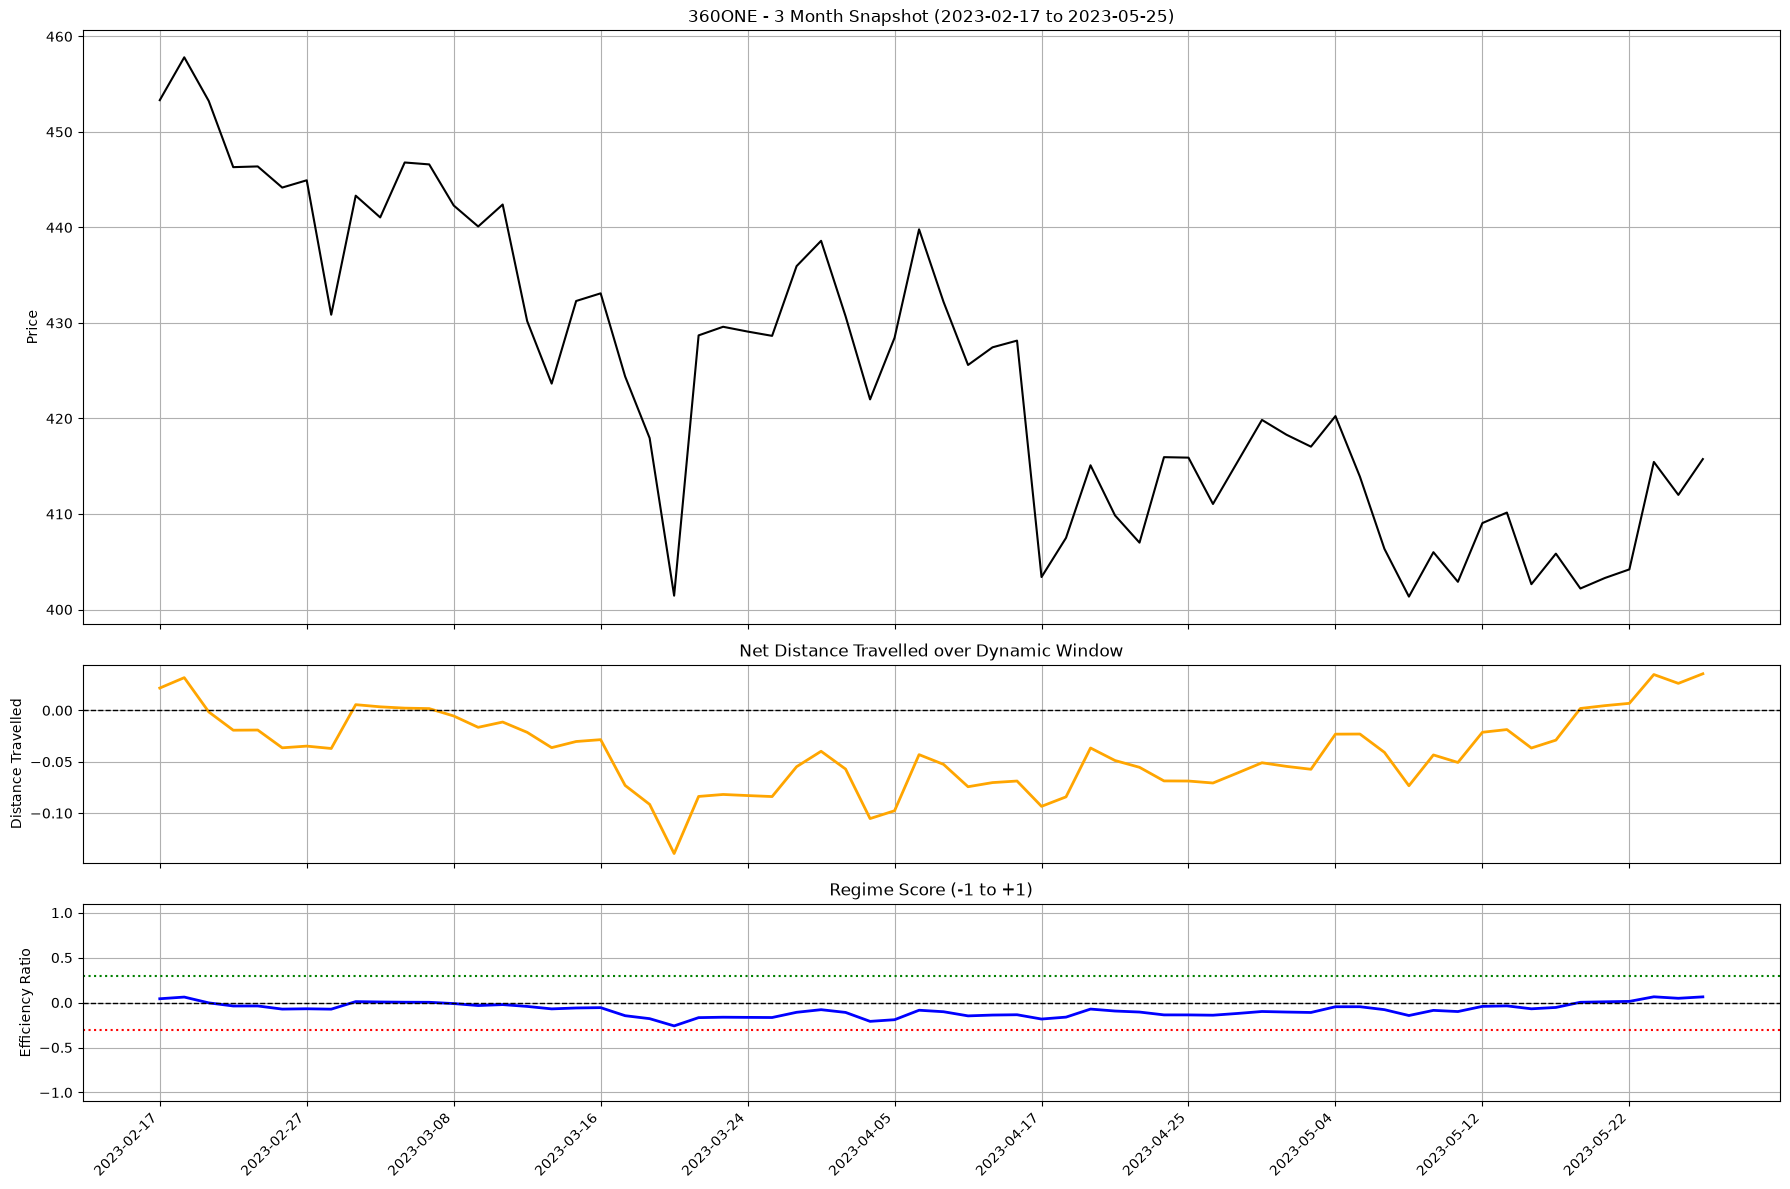


--- 360ONE Slice 2 ---


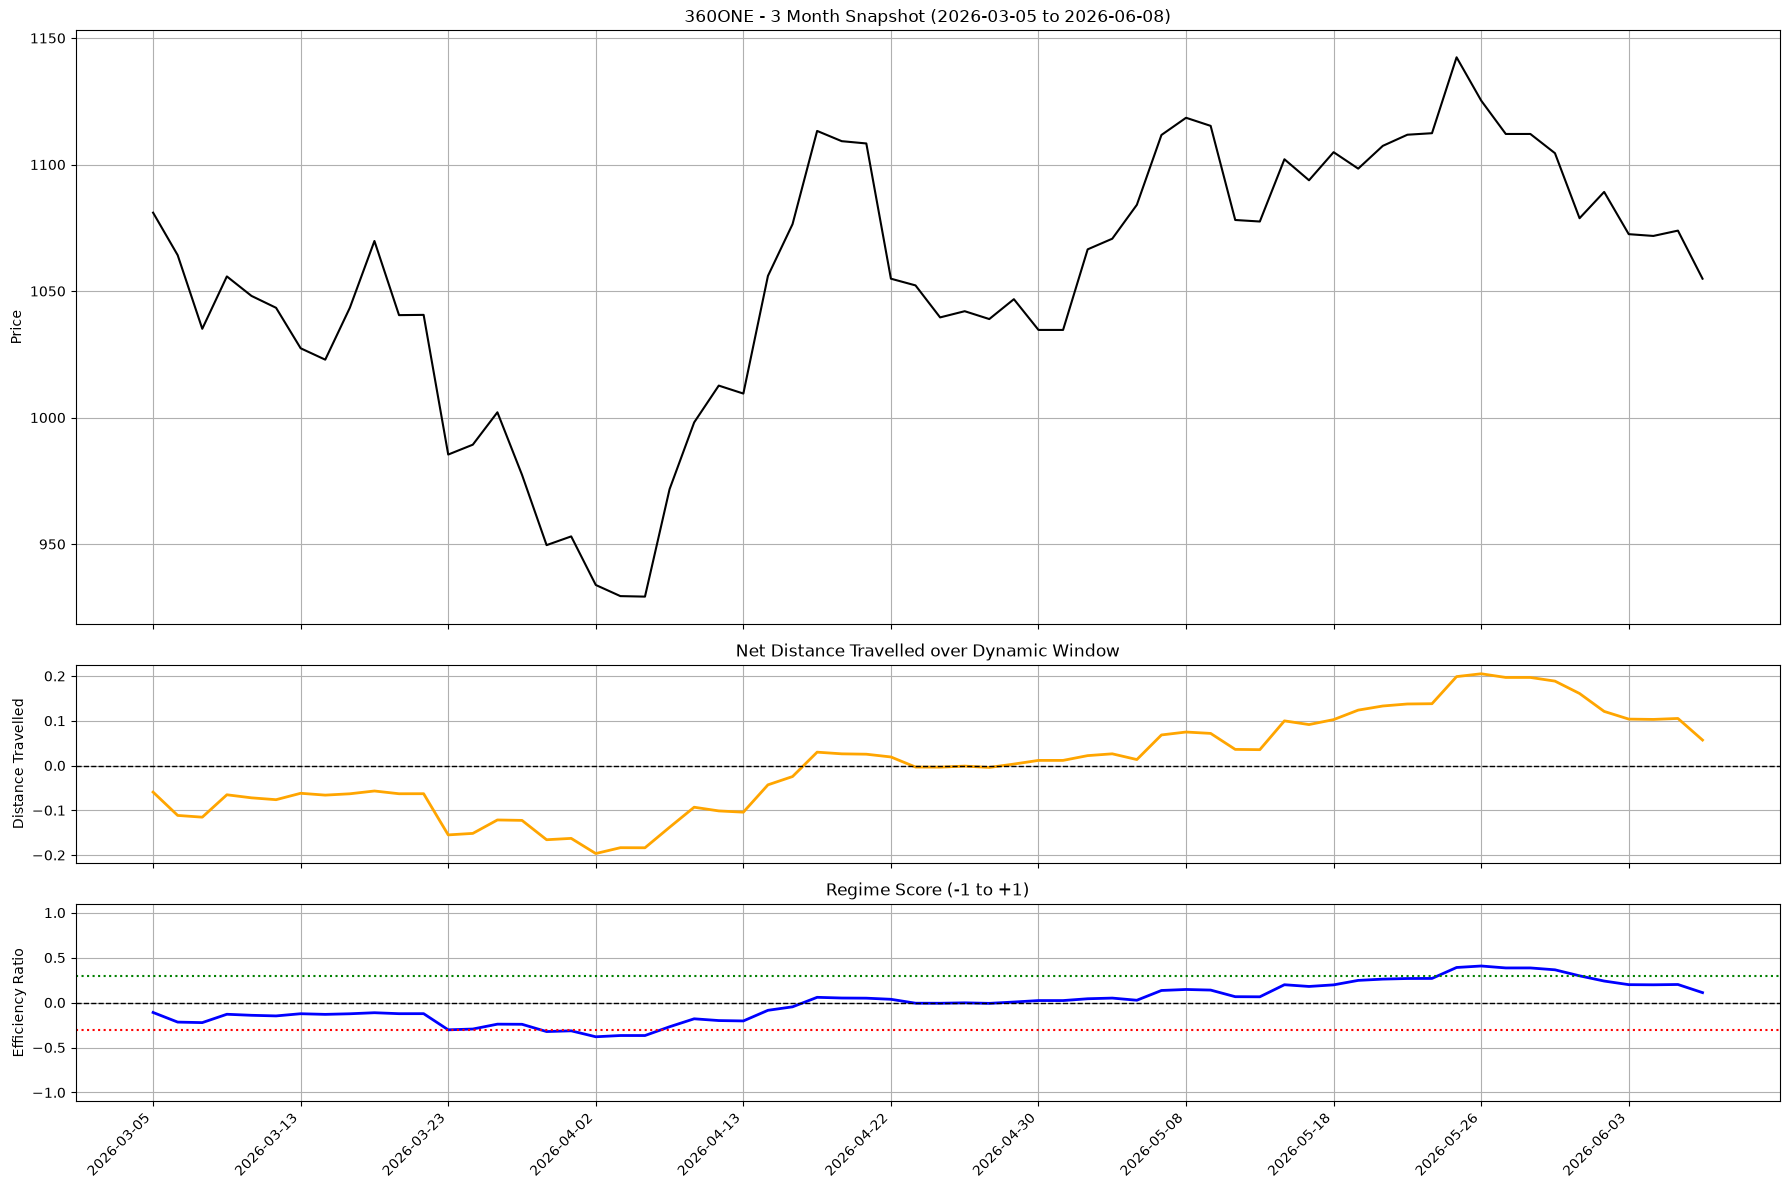


Processing 3MINDIA...



--- 3MINDIA Slice 1 ---


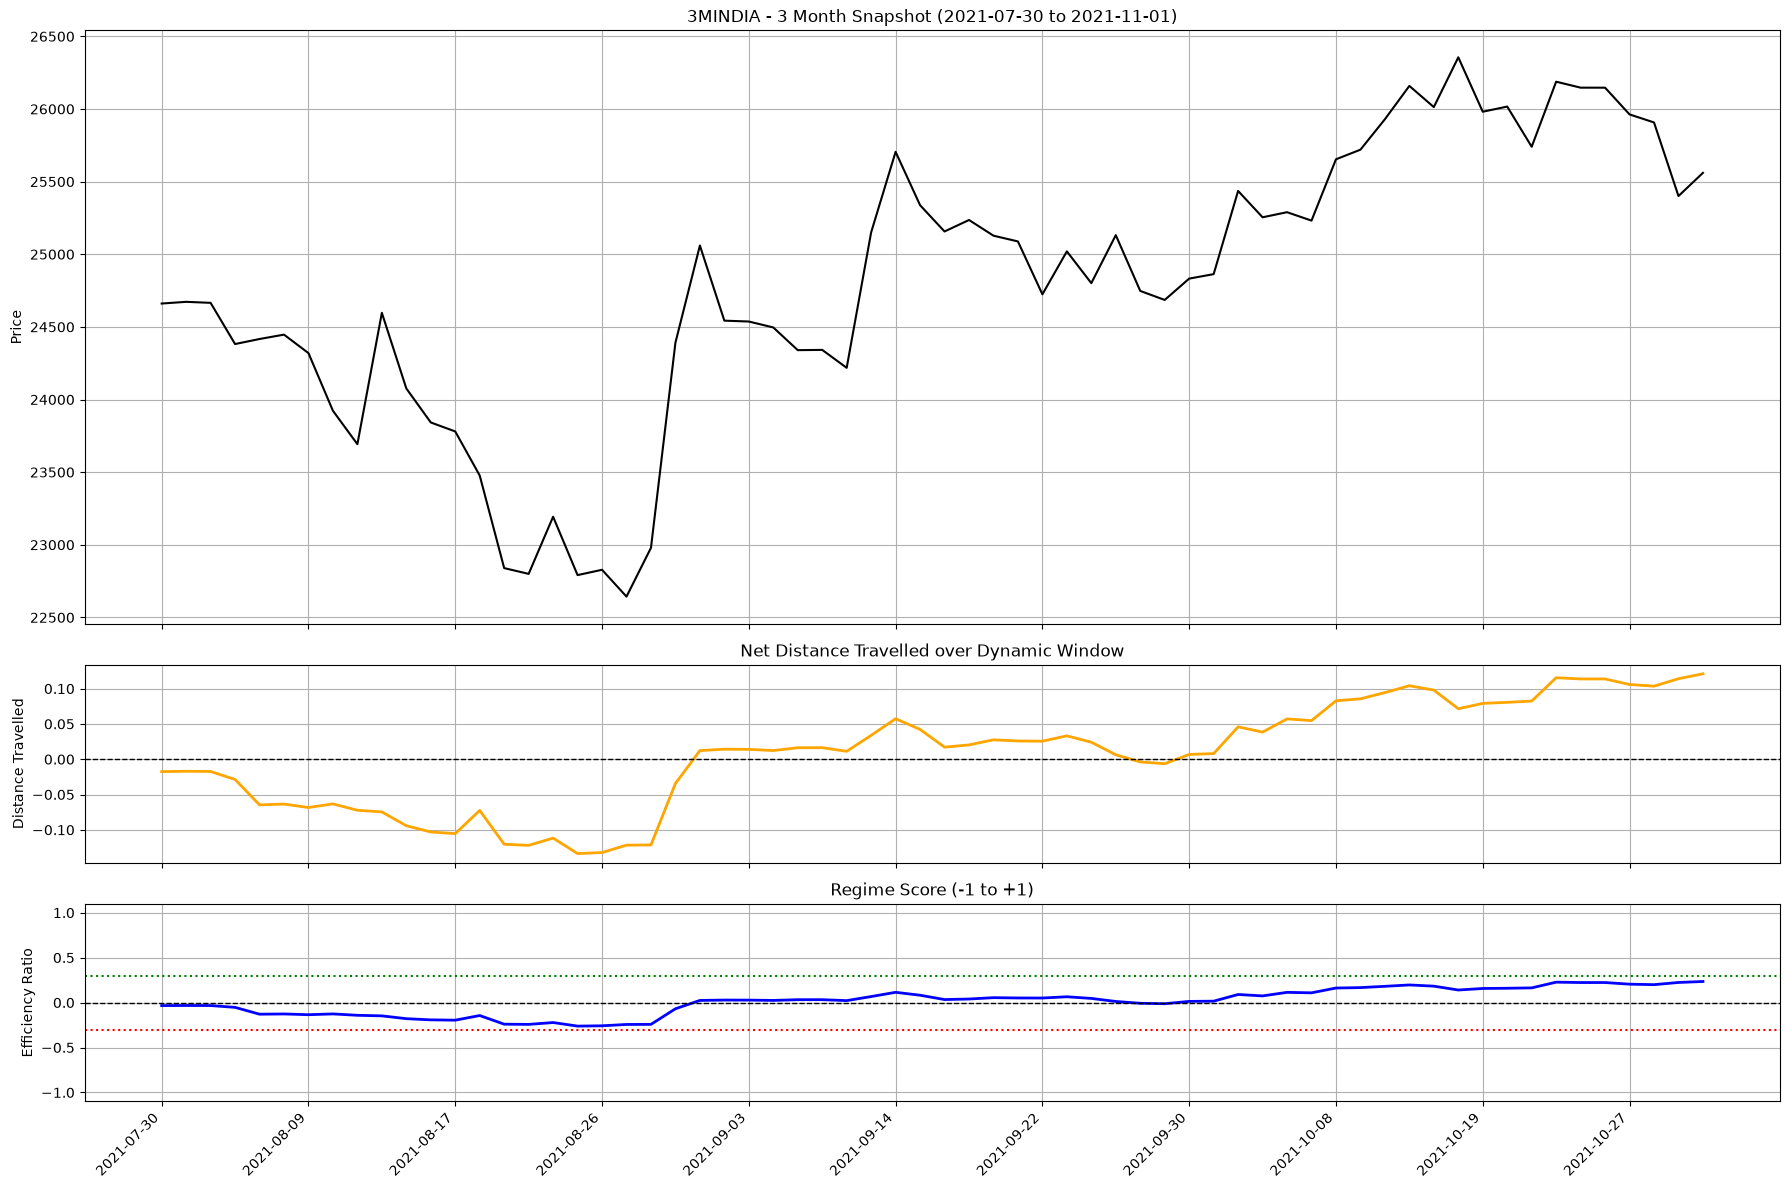


--- 3MINDIA Slice 2 ---


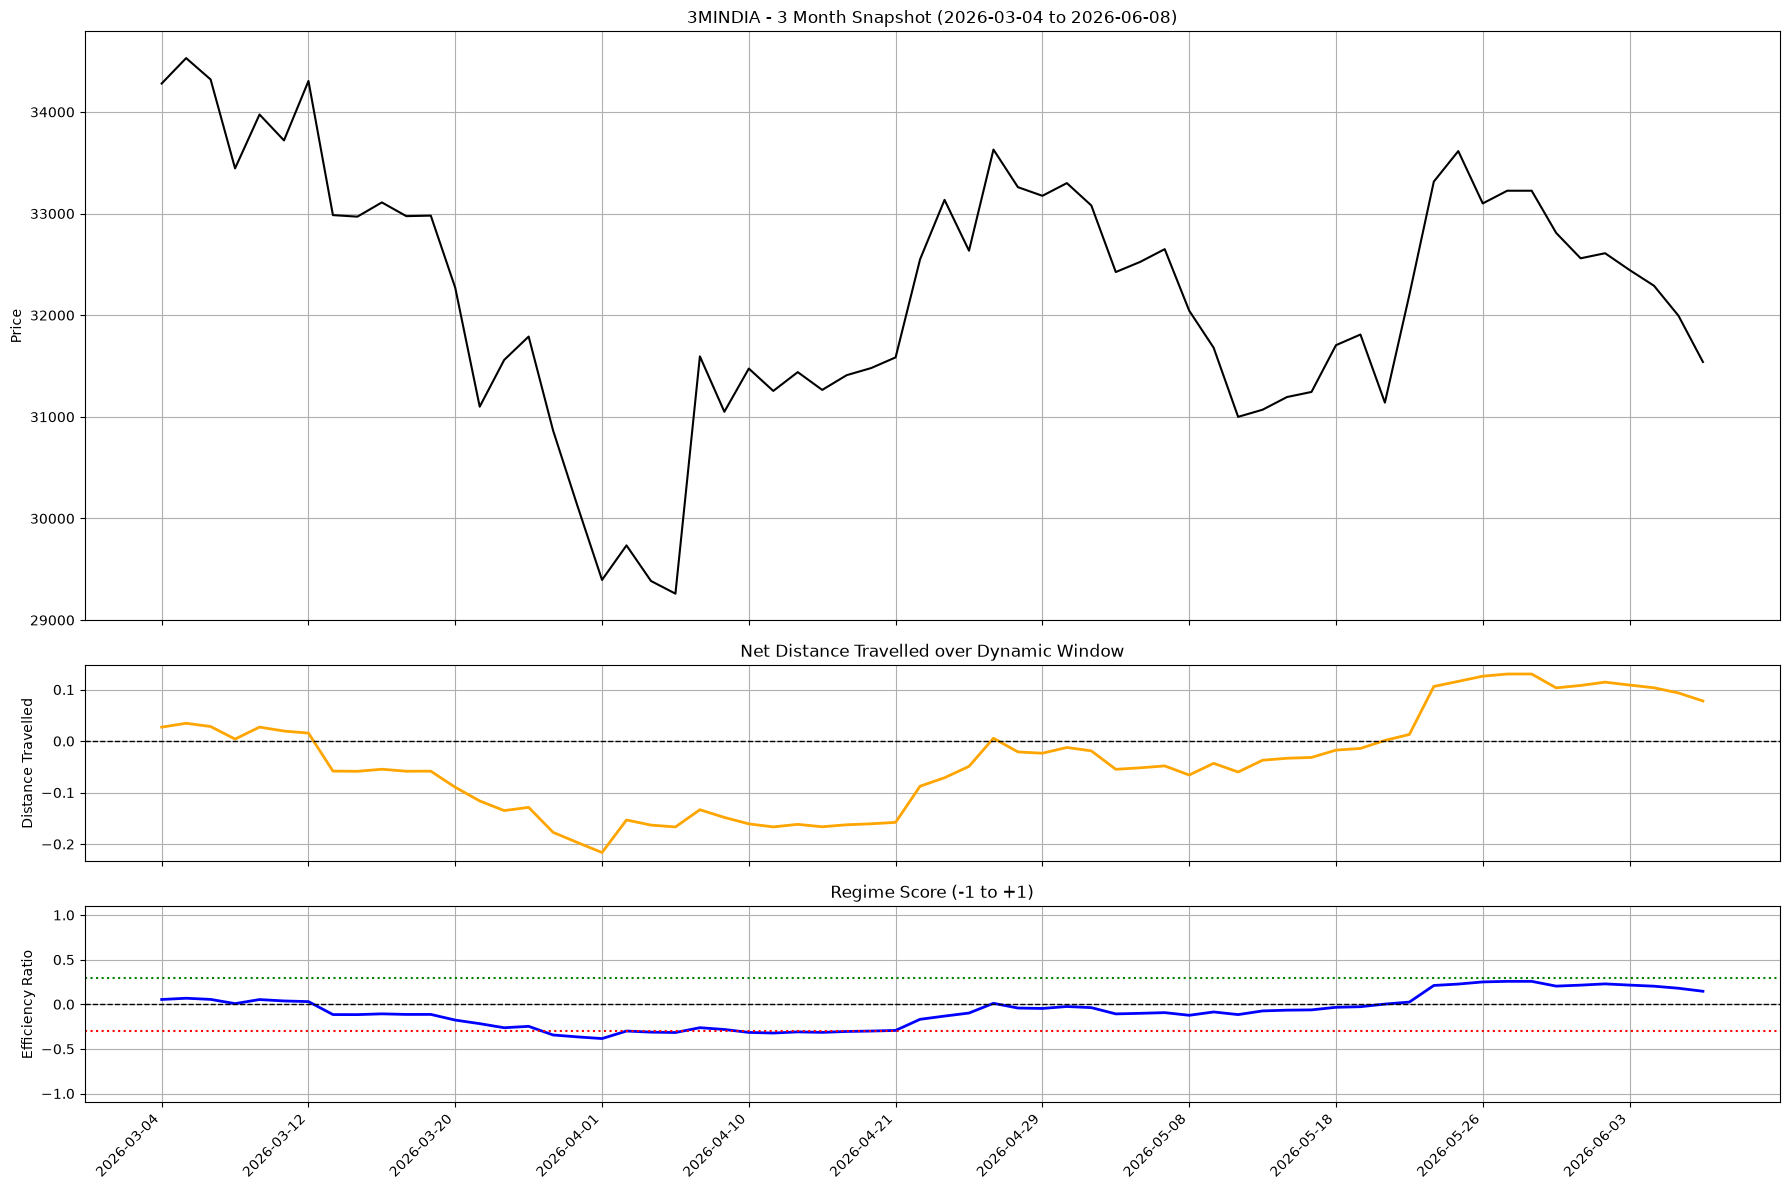


Processing AARTIDRUGS...



--- AARTIDRUGS Slice 1 ---


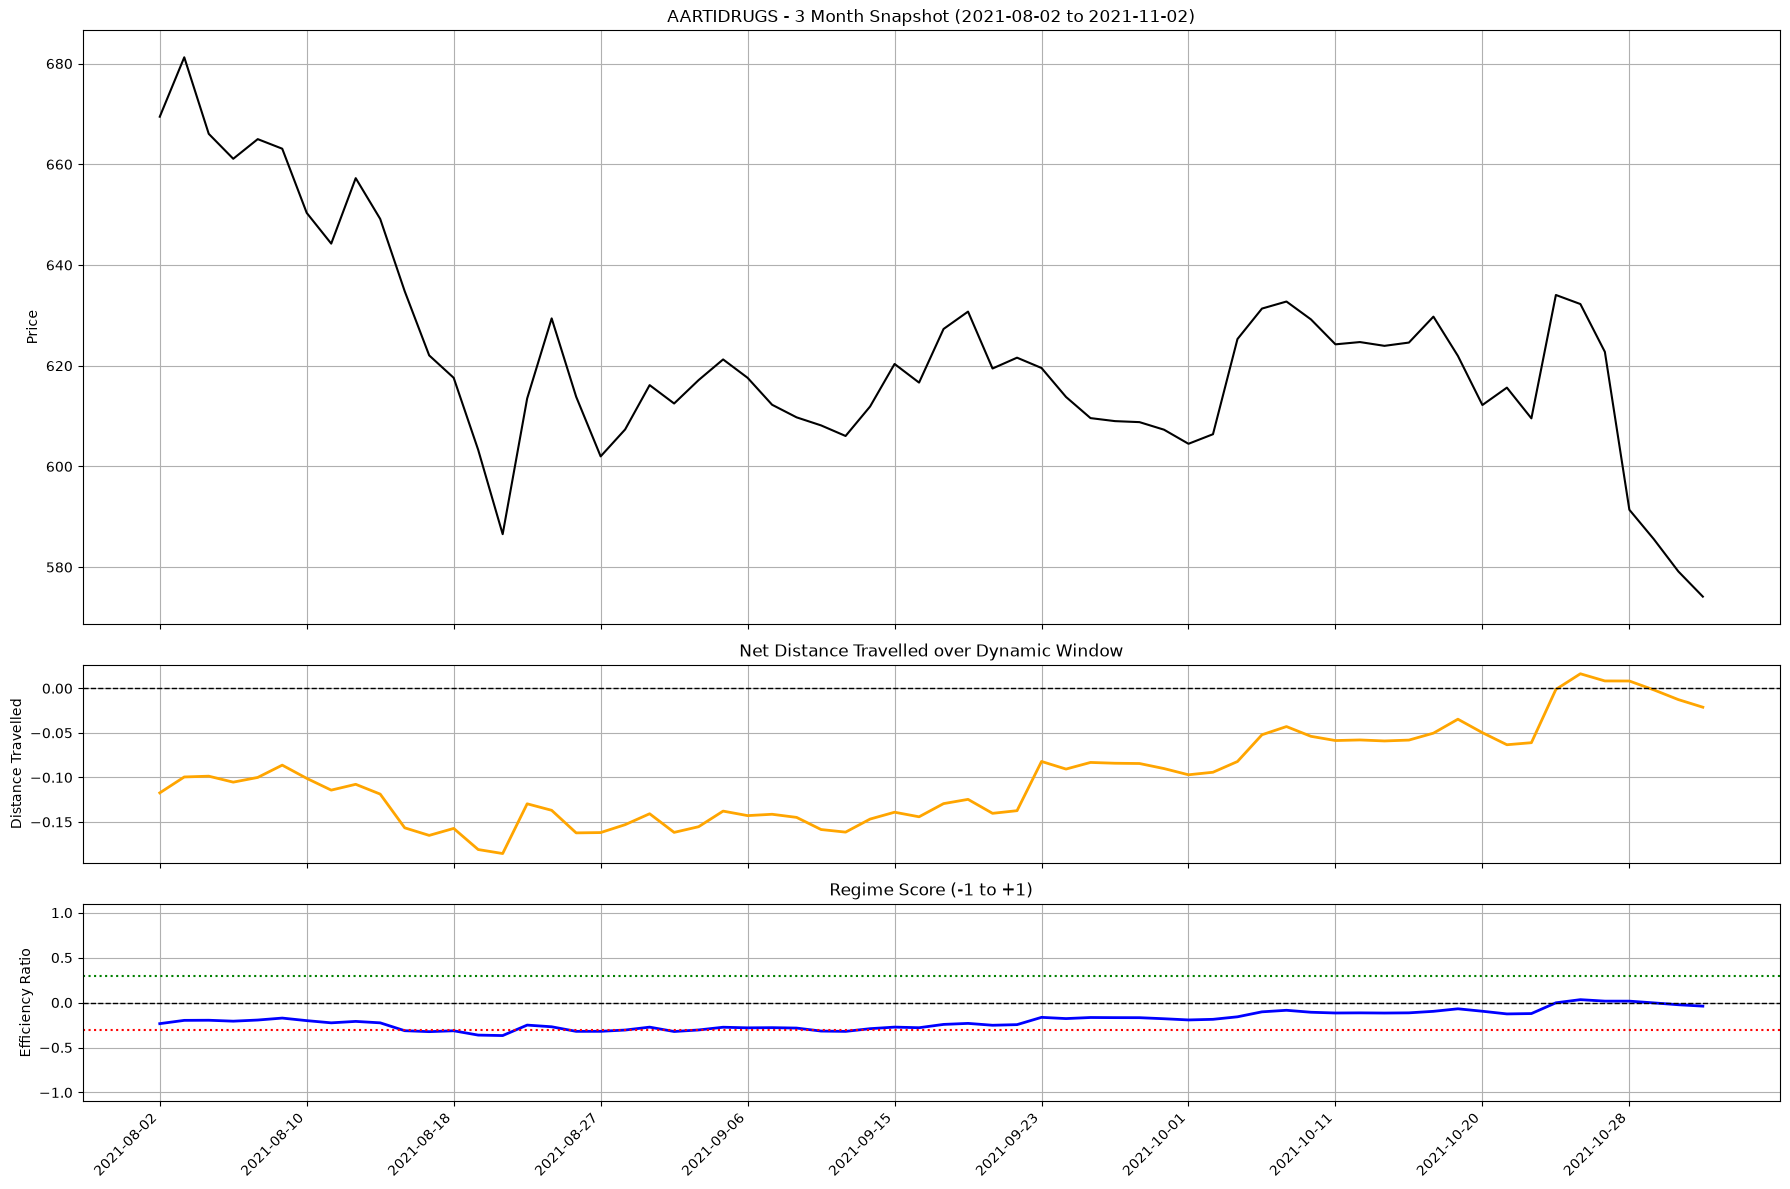


--- AARTIDRUGS Slice 2 ---


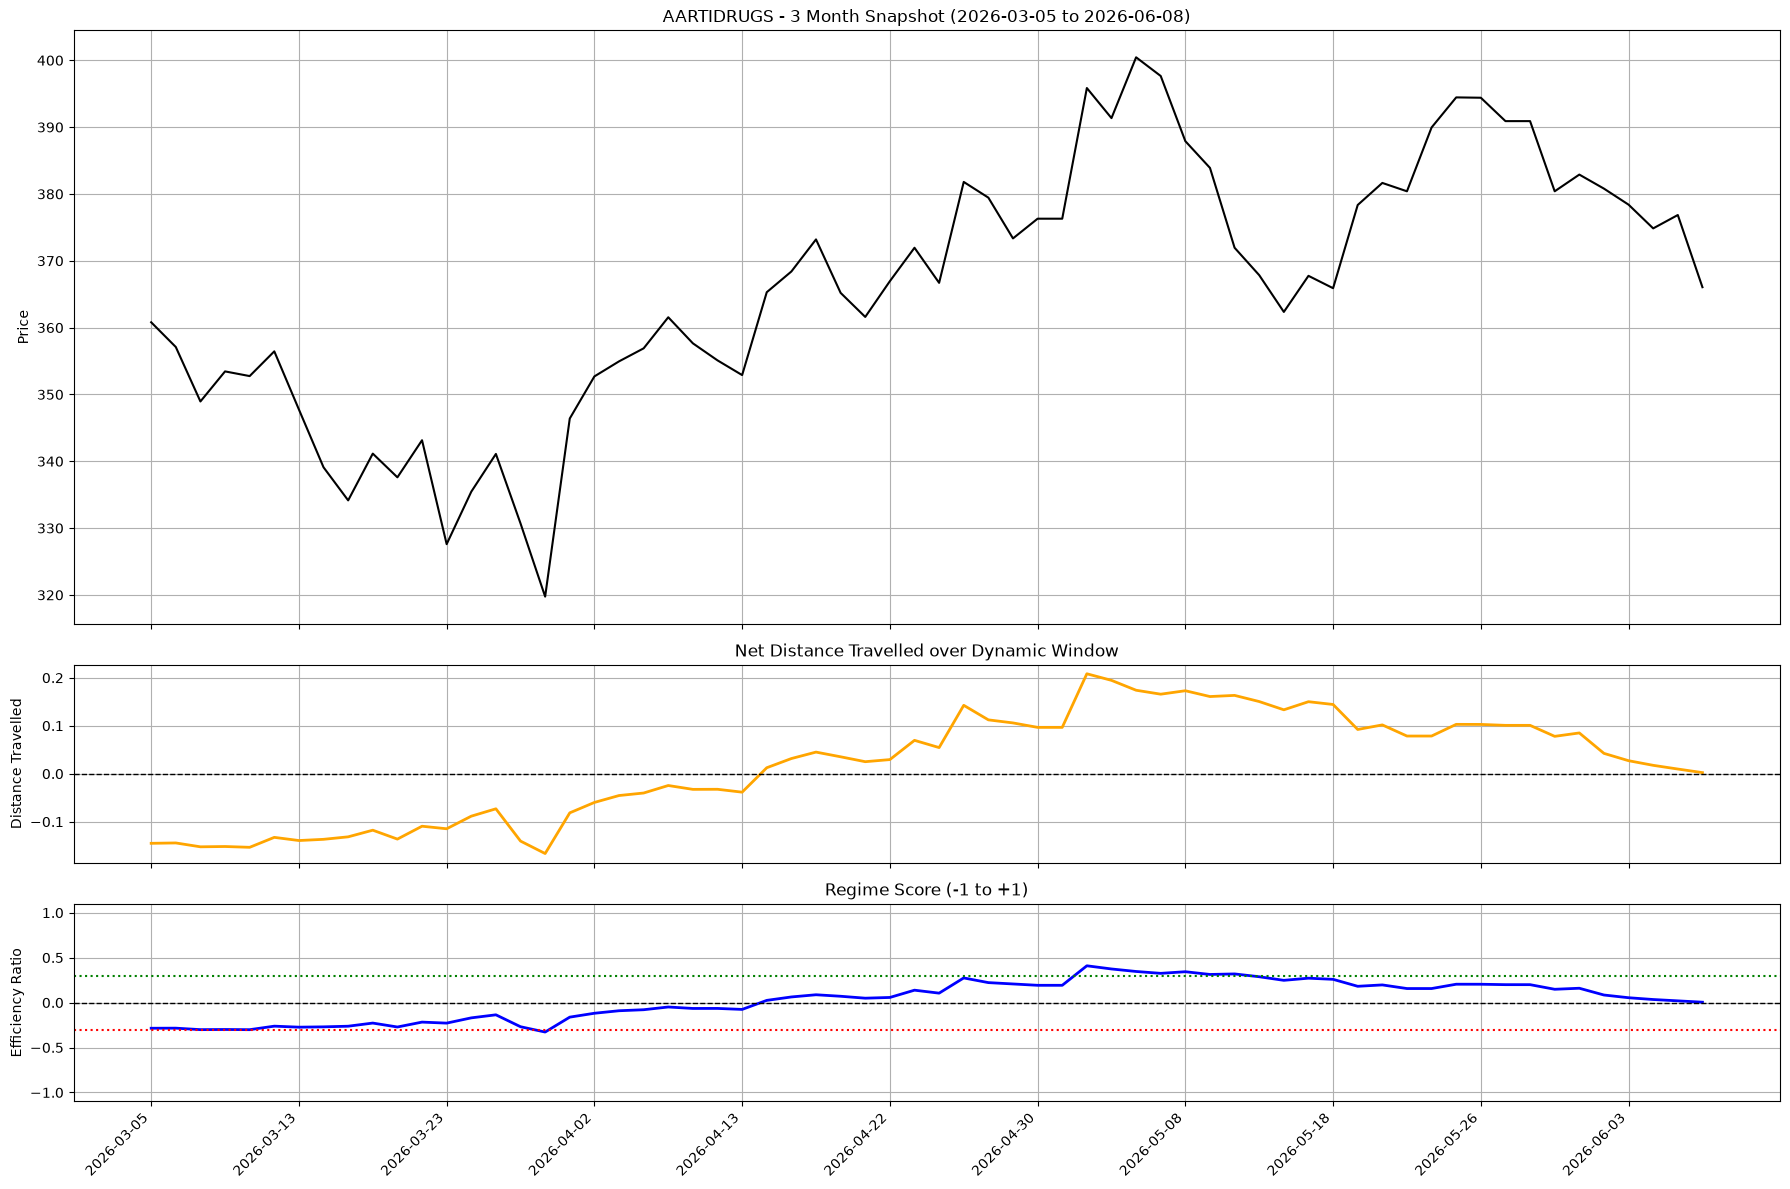


Processing AARTIIND...



--- AARTIIND Slice 1 ---


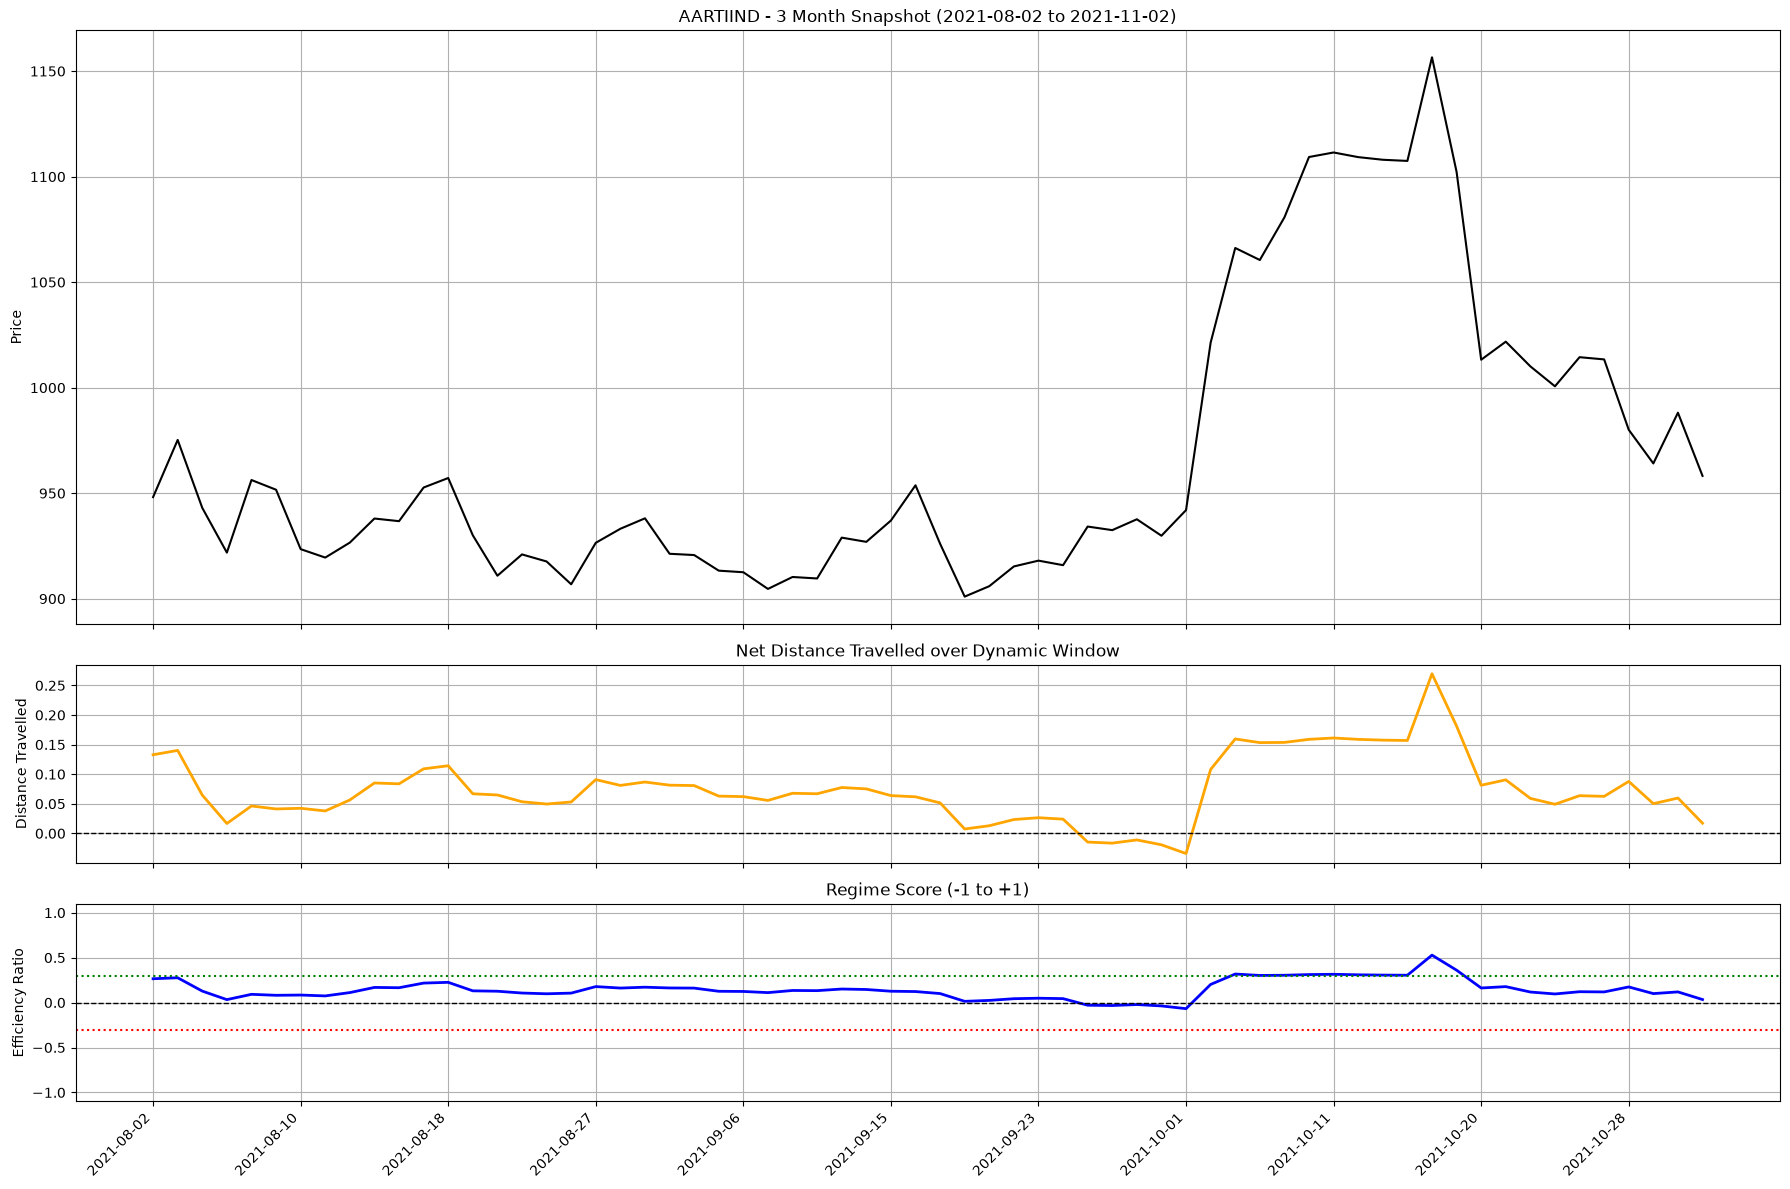


--- AARTIIND Slice 2 ---


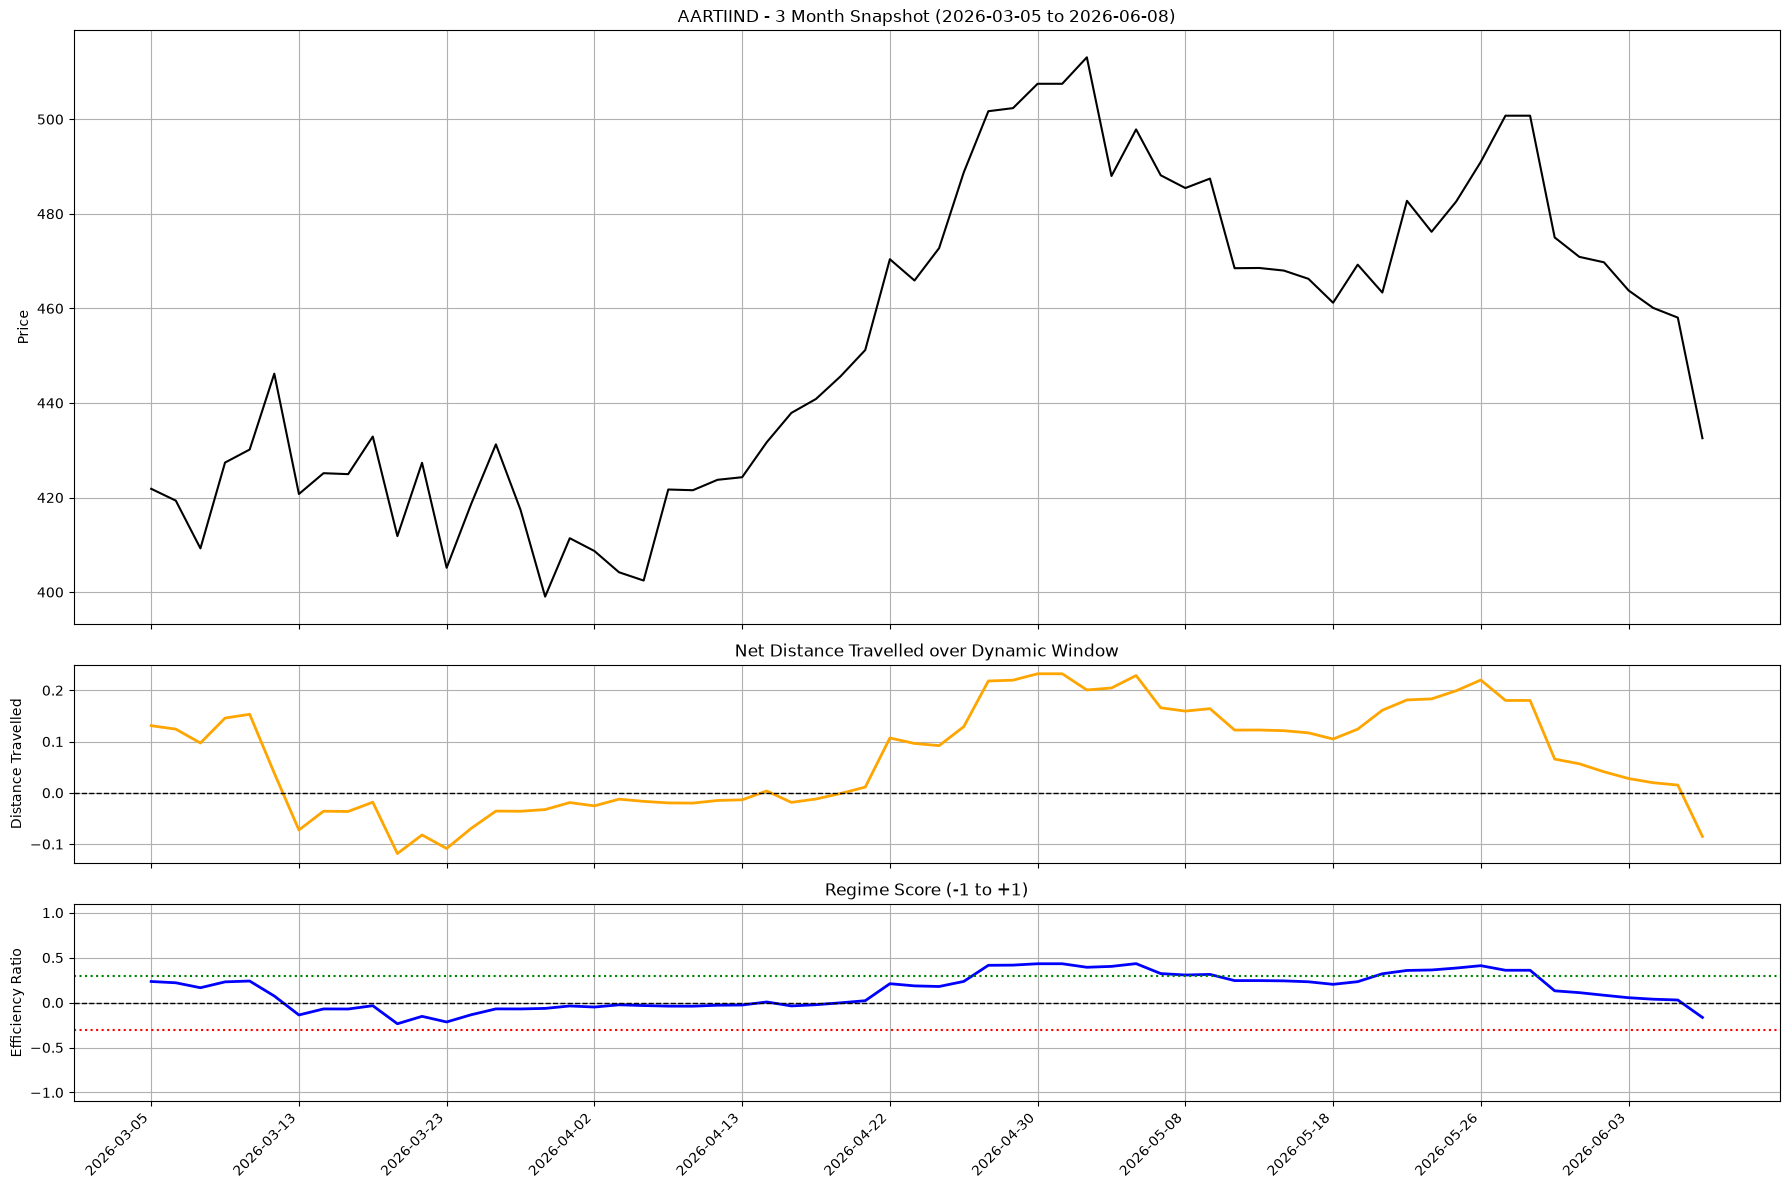


Processing AAVAS...



--- AAVAS Slice 1 ---


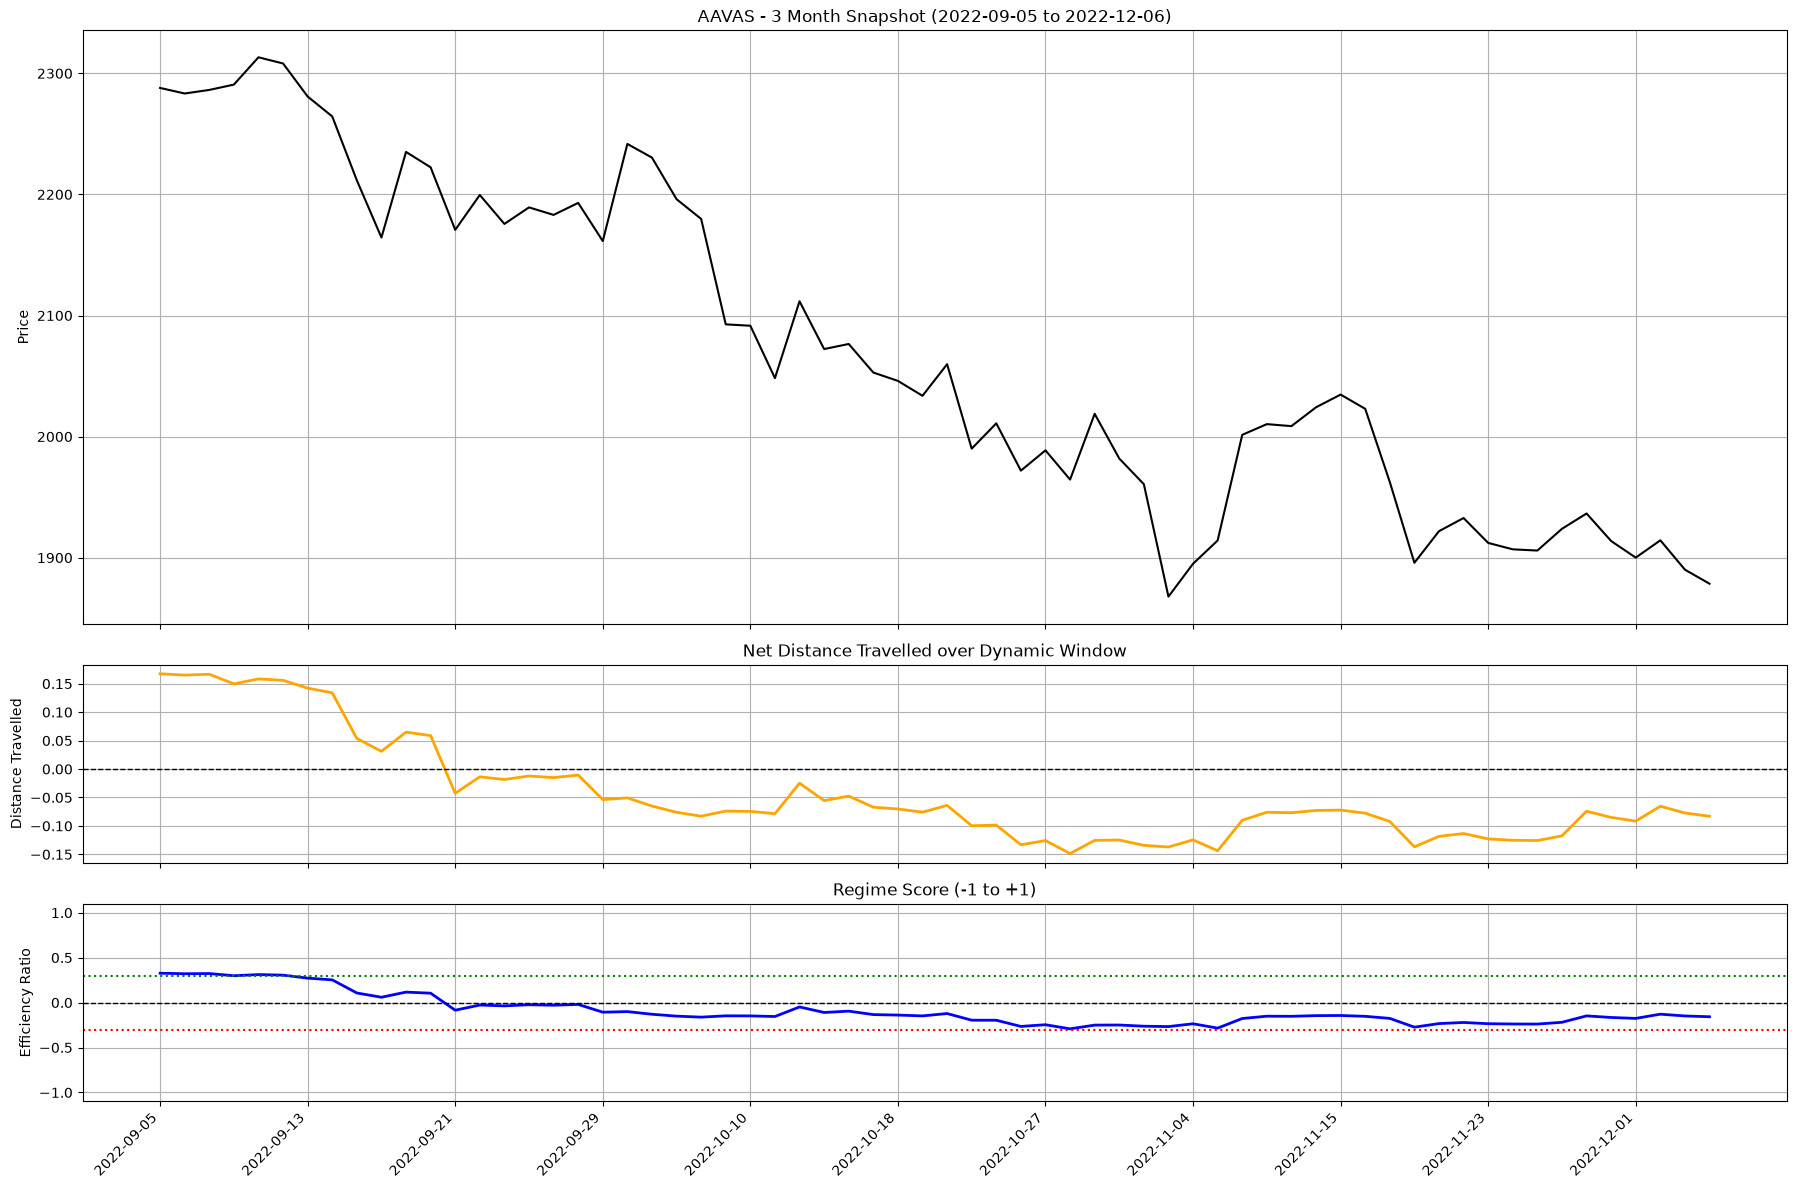


--- AAVAS Slice 2 ---


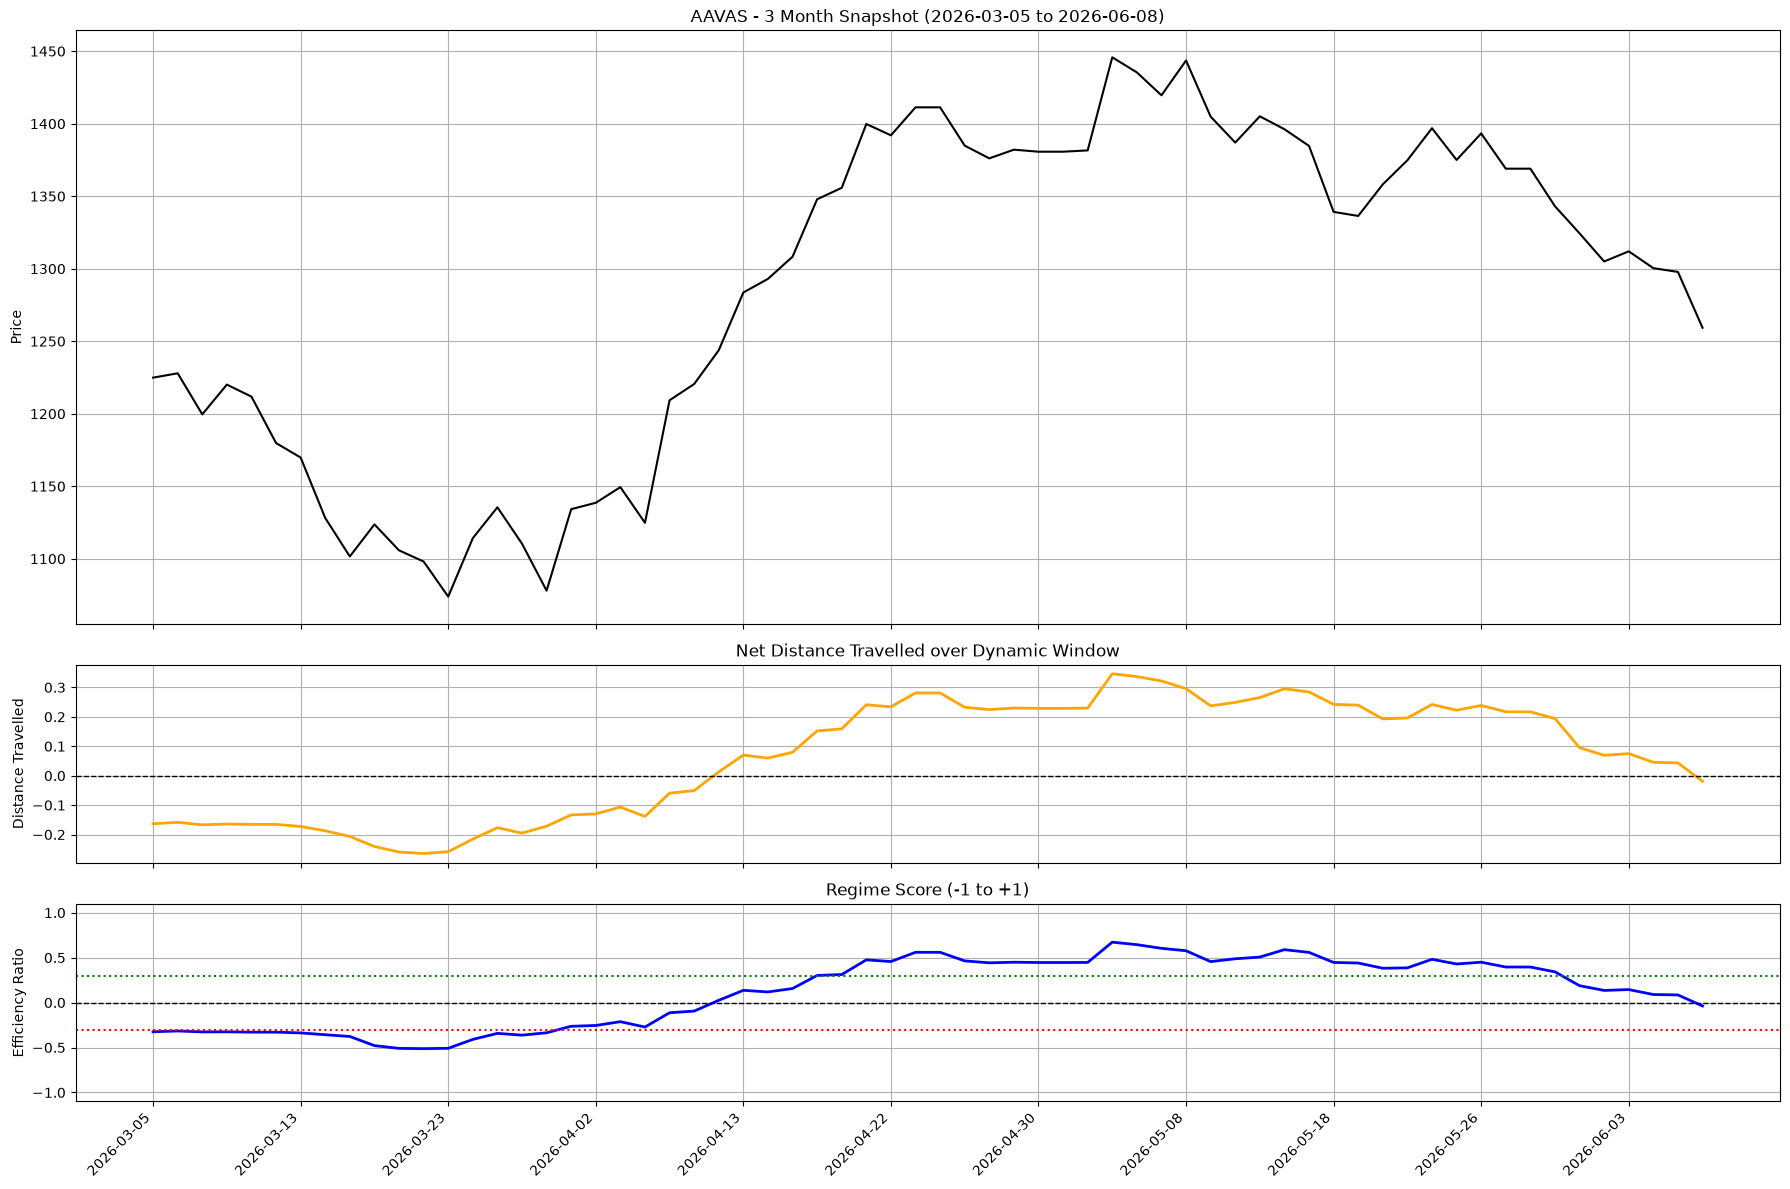

In [ ]:
# Set threshold to 50% cumulative price travel
CUMULATIVE_TARGET = 0.75 

for symbol, df in loaded_stocks.items():
    print(f"\n{'='*50}")
    print(f"Processing {symbol}...")
    df_processed = calculate_dynamic_regime(df, target=CUMULATIVE_TARGET)
    
    # Pick two completely arbitrary 3-month (63 trading days) periods that exist in the data
    # We'll pick one towards the middle, and one towards the end
    total_days = len(df_processed)
    if total_days > 400:
        slice1_start = total_days // 2
        slice2_start = total_days - 100
        
        print(f"\n--- {symbol} Slice 1 ---")
        plot_regime(df_processed, symbol, slice1_start, num_days=63)
        
        print(f"\n--- {symbol} Slice 2 ---")
        plot_regime(df_processed, symbol, slice2_start, num_days=63)
    else:
        print(f"Not enough data to plot slices for {symbol}.")
